In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from math import erf, sqrt

import geopandas as gpd

# ============================================================
# 0) 全局风格（更论文风）
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ============================================================
# 1) 读取数据（改这里）
# ============================================================
DATA_PATH = "/Crimes_-_2001_to_Present_20260212.csv"
LAT_COL, LON_COL = "Latitude", "Longitude"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[LAT_COL, LON_COL]).copy()
lat = df[LAT_COL].to_numpy()
lon = df[LON_COL].to_numpy()

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

# ============================================================
# 2) 读取并叠加 Chicago 边界（City boundary）
#   数据源：Chicago Data Portal Boundaries - City (GeoJSON endpoint)
# ============================================================
CITY_BOUNDARY_GEOJSON = "https://data.cityofchicago.org/resource/qqq8-j68g.geojson?$limit=50000"

def load_city_boundary():
    gdf = gpd.read_file(CITY_BOUNDARY_GEOJSON)
    # 统一到 WGS84 经纬度
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    else:
        gdf = gdf.to_crs(epsg=4326)
    return gdf

def add_chicago_boundary(ax, gdf, lw=1.6):
    # 只画轮廓
    gdf.boundary.plot(ax=ax, linewidth=lw, color="black", alpha=0.9, zorder=10)

city_gdf = load_city_boundary()






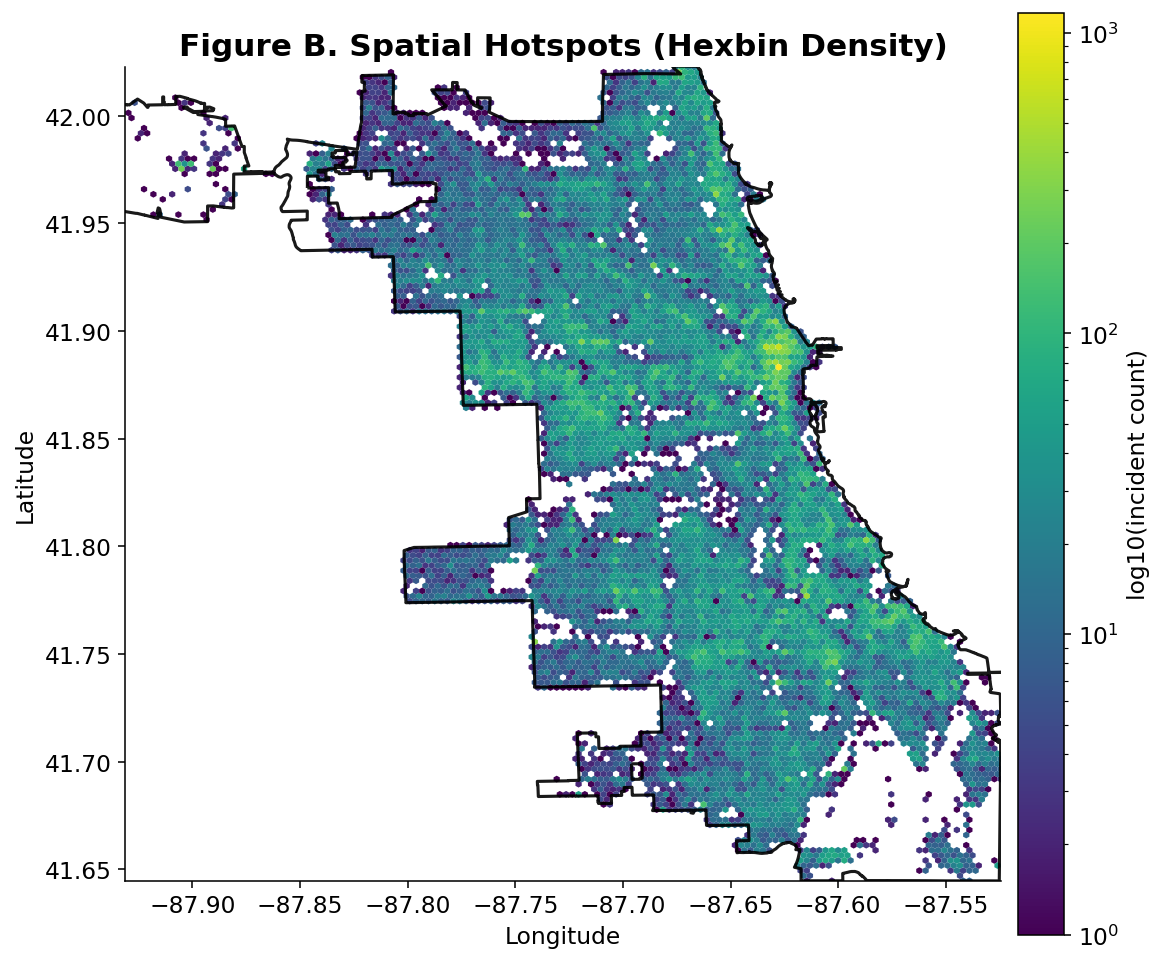

In [7]:
# ============================================================
# Figure B: Hexbin density（美化：log色标 + equal aspect + 边界）
# ============================================================
fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)
hb = ax.hexbin(
    lon, lat,
    gridsize=140,
    mincnt=1,
    bins="log",
    linewidths=0.0
)
add_chicago_boundary(ax, city_gdf, lw=1.6)

ax.set_title("Figure B. Spatial Hotspots (Hexbin Density)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_aspect("equal", adjustable="box")

cb = fig.colorbar(hb, ax=ax, shrink=0.9, pad=0.02)
cb.set_label("log10(incident count)")

fig.savefig("pretty_B_hexbin.png")
plt.show()

Figure B (Hexbin Density).
Figure B maps incident intensity across Chicago using a hexbin density surface (log10 scale). The map shows strong spatial heterogeneity: incidents are widely distributed, but density is clearly higher in a broad band running through the central–eastern portion of the city, with localized peaks near the lakefront side of the urban core. In contrast, large portions of the far west/southwest and peripheral areas display much lower densities and more fragmented coverage. Overall, the density pattern suggests that incidents are not randomly scattered; instead, they form geographically coherent clusters that likely align with where people, activity nodes, and transport corridors concentrate.
图 B 使用六边形网格（hexbin）对芝加哥的事件分布进行密度可视化，并用 log10 颜色刻度突出高低差异。整体来看，事件在城市空间上呈现明显的“非均匀分布”：并非平均散布在全市，而是在若干连片区域形成更高密度的聚集带，尤其在城市中东部/靠近湖岸的一侧出现更突出的高值区域；相比之下，城市边缘或部分区域密度较低且更零散。该图首先提供了直观证据：事件存在可识别的热点结构，而不是随机点状分布。

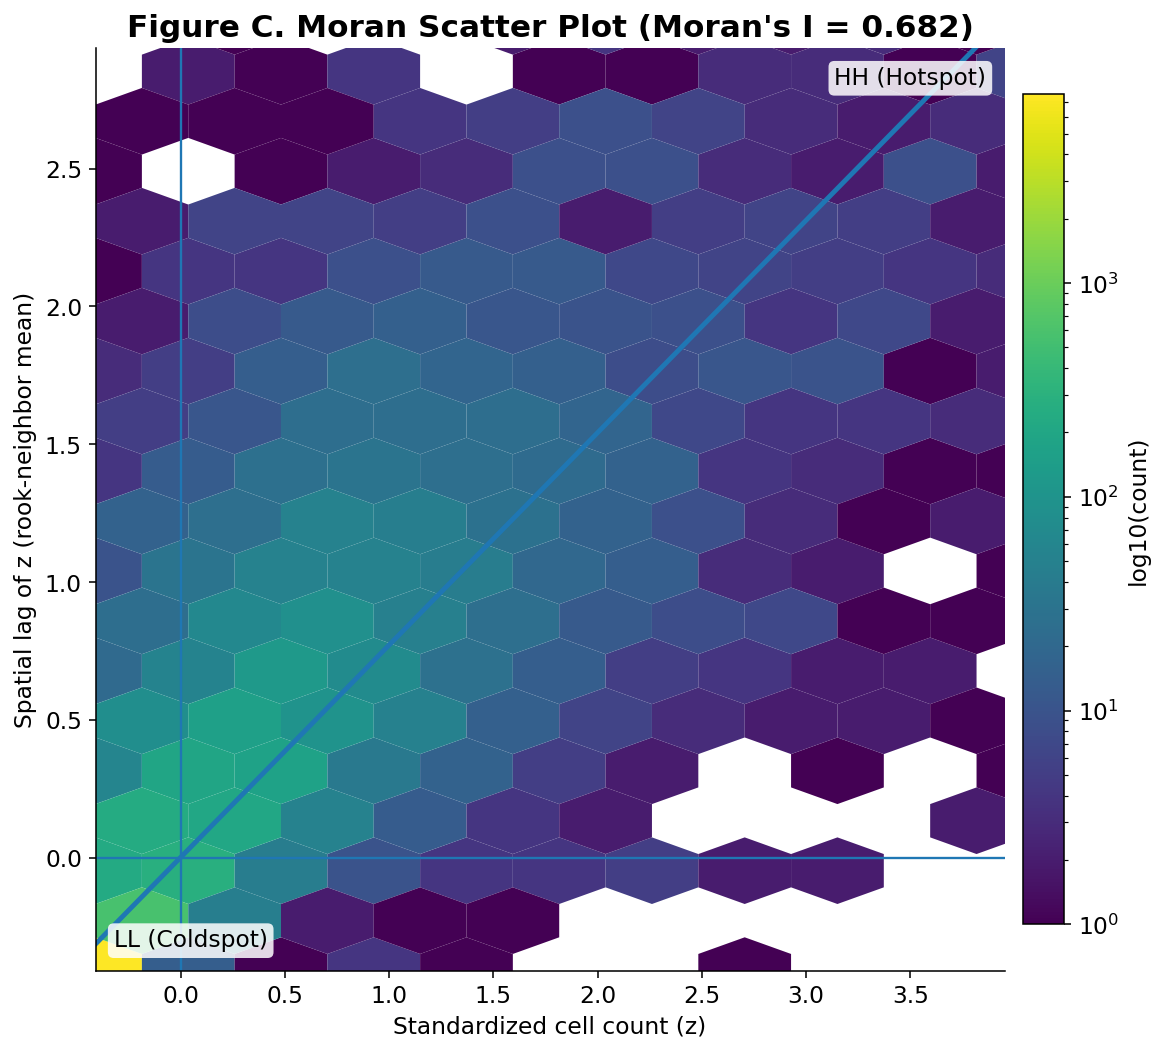

Moran's I = 0.6821263491197647


In [8]:
# ============================================================
# Figure C: Moran scatter（美化版：用 hexbin 密度而不是糊点）
#   - 先栅格化计数
#   - rook 邻居
#   - Moran's I
# ============================================================
nx_c, ny_c = 110, 110
ix = np.clip(((lon - lon_min) / (lon_max - lon_min) * (nx_c - 1)).astype(int), 0, nx_c - 1)
iy = np.clip(((lat - lat_min) / (lat_max - lat_min) * (ny_c - 1)).astype(int), 0, ny_c - 1)

counts = np.zeros((ny_c, nx_c), dtype=float)
np.add.at(counts, (iy, ix), 1.0)

z = (counts - counts.mean()) / (counts.std(ddof=0) if counts.std(ddof=0) > 0 else 1.0)

# rook neighbor lag
zp = np.pad(z, 1, mode="constant", constant_values=0.0)
neighbor_sum = (
    zp[0:ny_c,   1:nx_c+1] +
    zp[2:ny_c+2, 1:nx_c+1] +
    zp[1:ny_c+1, 0:nx_c  ] +
    zp[1:ny_c+1, 2:nx_c+2]
)
ones = np.ones_like(z)
op = np.pad(ones, 1, mode="constant", constant_values=0.0)
neighbor_cnt = (
    op[0:ny_c,   1:nx_c+1] +
    op[2:ny_c+2, 1:nx_c+1] +
    op[1:ny_c+1, 0:nx_c  ] +
    op[1:ny_c+1, 2:nx_c+2]
)
lag = np.divide(neighbor_sum, neighbor_cnt, out=np.zeros_like(neighbor_sum), where=neighbor_cnt > 0)

z_flat = z.ravel()
lag_flat = lag.ravel()

# Moran's I using lag = Wz
I = float(np.sum(z_flat * lag_flat) / np.sum(z_flat**2))

def plot_moran_pretty(z_flat, lag_flat, I, out_path="pretty_C_moran.png"):
    fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)

    # 裁剪极端点，让画面干净
    x1, x2 = np.percentile(z_flat, [1, 99])
    y1, y2 = np.percentile(lag_flat, [1, 99])
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)

    hb = ax.hexbin(
        z_flat, lag_flat,
        gridsize=70,
        bins="log",
        mincnt=1,
        linewidths=0
    )
    cb = fig.colorbar(hb, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label("log10(count)")

    # 趋势线（在范围内拟合）
    mask = (z_flat >= x1) & (z_flat <= x2) & (lag_flat >= y1) & (lag_flat <= y2)
    m, b = np.polyfit(z_flat[mask], lag_flat[mask], 1)
    xs = np.array([x1, x2])
    ax.plot(xs, m * xs + b, linewidth=2.5)

    ax.axhline(0, linewidth=1.2)
    ax.axvline(0, linewidth=1.2)

    box = dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="none")
    ax.text(0.98, 0.98, "HH (Hotspot)", transform=ax.transAxes, ha="right", va="top", bbox=box)
    ax.text(0.02, 0.02, "LL (Coldspot)", transform=ax.transAxes, ha="left", va="bottom", bbox=box)

    ax.set_title(f"Figure C. Moran Scatter Plot (Moran's I = {I:.3f})")
    ax.set_xlabel("Standardized cell count (z)")
    ax.set_ylabel("Spatial lag of z (rook-neighbor mean)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.savefig(out_path, dpi=300)
    plt.show()

plot_moran_pretty(z_flat, lag_flat, I, out_path="pretty_C_moran_scatter.png")
print("Moran's I =", I)





Figure C (Moran Scatter Plot).
Figure C assesses whether the clustering seen in Figure B reflects true spatial dependence. The Moran scatter plot relates each grid cell’s standardized incident count (z) to the mean standardized count of its rook-adjacent neighbors (spatial lag). The strong positive slope and a high Moran’s I (0.682) indicate substantial positive spatial autocorrelation, meaning high-count cells tend to be surrounded by high-count neighbors (HH), and low-count cells tend to be near low-count neighbors (LL). This rules out a purely “spotty” or random pattern and supports the interpretation that incident risk is spatially structured—consistent with neighborhood-level processes and spillovers rather than isolated single-cell spikes.

图 C 用 Moran 散点图检验上述聚集是否体现真实的空间依赖性。横轴是每个网格单元的标准化事件数（z），纵轴是其相邻网格（rook 邻接）的标准化均值（空间滞后）。图中呈现明显的正向趋势，并且 Moran’s I = 0.682，说明存在较强的正空间自相关：高值网格倾向于被高值邻居包围（HH），低值网格也倾向于与低值邻居相邻（LL）。这意味着事件分布具有显著的空间结构，不太可能仅由随机波动造成，为后续采用空间特征或空间模型提供了统计层面的支撑。

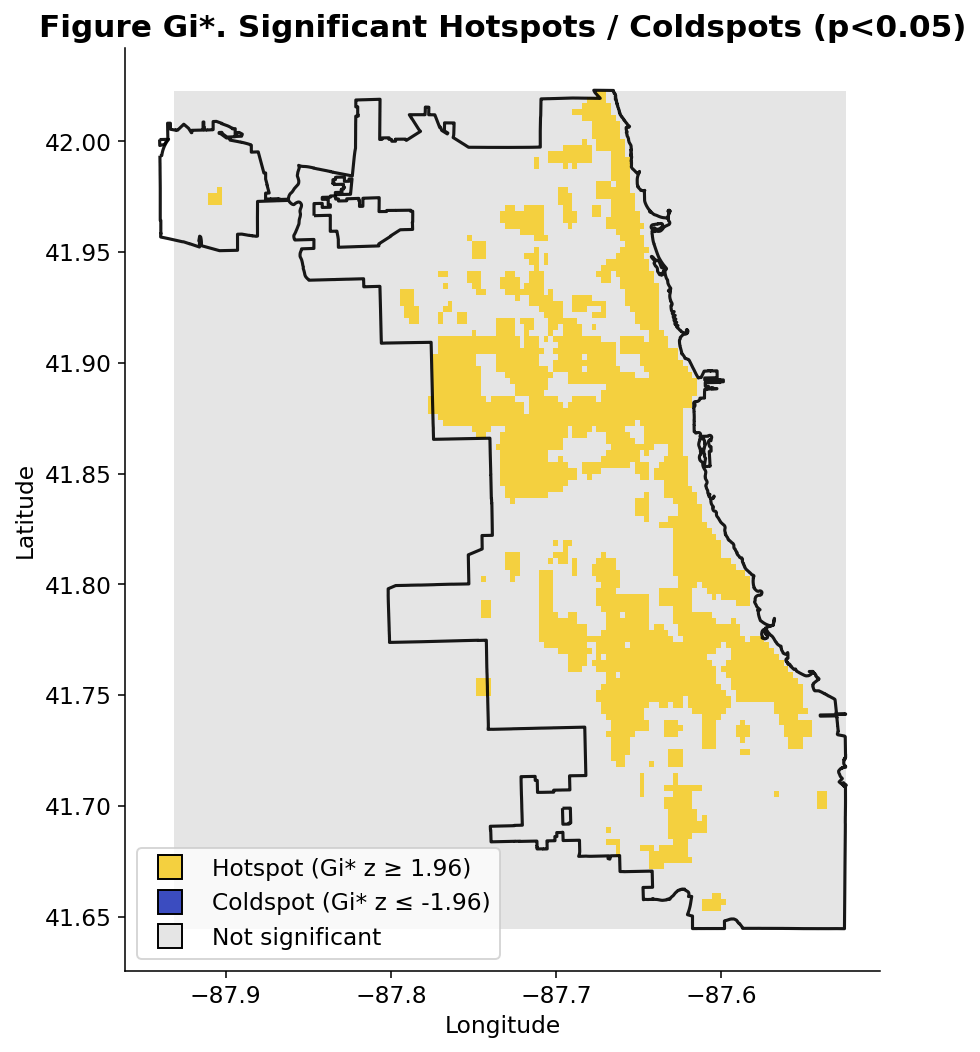

Gi* z-score max/min: 41.571915097637614 -1.1313540285696986
Significant cells: 2660 / 19600


In [9]:
# ============================================================
# Figure Gi*: 显著热点/冷点分类图（更漂亮：离散色 + legend + 边界）
# ============================================================
nx_g, ny_g = 140, 140
ixg = np.clip(((lon - lon_min) / (lon_max - lon_min) * (nx_g - 1)).astype(int), 0, nx_g - 1)
iyg = np.clip(((lat - lat_min) / (lat_max - lat_min) * (ny_g - 1)).astype(int), 0, ny_g - 1)

x = np.zeros((ny_g, nx_g), dtype=float)
np.add.at(x, (iyg, ixg), 1.0)

x_flat = x.ravel()
n = x_flat.size
Xbar = x_flat.mean()
S = x_flat.std(ddof=0) if x_flat.std(ddof=0) > 0 else 1.0

# queen 3x3 neighborhood
xp = np.pad(x, 1, mode="constant", constant_values=0.0)
sum_wx = (
    xp[0:ny_g,   0:nx_g]   + xp[0:ny_g,   1:nx_g+1] + xp[0:ny_g,   2:nx_g+2] +
    xp[1:ny_g+1, 0:nx_g]   + xp[1:ny_g+1, 1:nx_g+1] + xp[1:ny_g+1, 2:nx_g+2] +
    xp[2:ny_g+2, 0:nx_g]   + xp[2:ny_g+2, 1:nx_g+1] + xp[2:ny_g+2, 2:nx_g+2]
)

ones = np.ones_like(x)
op = np.pad(ones, 1, mode="constant", constant_values=0.0)
sum_w = (
    op[0:ny_g,   0:nx_g]   + op[0:ny_g,   1:nx_g+1] + op[0:ny_g,   2:nx_g+2] +
    op[1:ny_g+1, 0:nx_g]   + op[1:ny_g+1, 1:nx_g+1] + op[1:ny_g+1, 2:nx_g+2] +
    op[2:ny_g+2, 0:nx_g]   + op[2:ny_g+2, 1:nx_g+1] + op[2:ny_g+2, 2:nx_g+2]
)
sum_w2 = sum_w

denom = S * np.sqrt((n * sum_w2 - (sum_w ** 2)) / (n - 1))
z_gi = np.divide(sum_wx - Xbar * sum_w, denom, out=np.zeros_like(sum_wx), where=denom > 0)

def norm_cdf(zv):
    return 0.5 * (1.0 + erf(zv / sqrt(2.0)))

p_two = 2.0 * (1.0 - np.vectorize(norm_cdf)(np.abs(z_gi)))
sig = (p_two < 0.05)

hot = (z_gi >= 1.96) & sig
cold = (z_gi <= -1.96) & sig

cat = np.zeros_like(z_gi)
cat[hot] = 1
cat[cold] = -1

# 离散颜色：cold / not sig / hot
cmap = ListedColormap(["#3b4cc0", "#e5e5e5", "#f4d03f"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)
ax.imshow(
    cat, origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap=cmap, norm=norm, aspect="equal"
)
add_chicago_boundary(ax, city_gdf, lw=1.6)

ax.set_title("Figure Gi*. Significant Hotspots / Coldspots (p<0.05)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

legend_elems = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#f4d03f",
           markersize=12, label="Hotspot (Gi* z ≥ 1.96)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#3b4cc0",
           markersize=12, label="Coldspot (Gi* z ≤ -1.96)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#e5e5e5",
           markersize=12, label="Not significant"),
]
ax.legend(handles=legend_elems, loc="lower left", frameon=True)

fig.savefig("pretty_GiStar_classes.png", dpi=300)
plt.show()

print("Gi* z-score max/min:", float(np.nanmax(z_gi)), float(np.nanmin(z_gi)))
print("Significant cells:", int(sig.sum()), "/", sig.size)

Figure Gi* (Significant hotspot/coldspot classes, p < 0.05).
The Gi* significance classification map (p < 0.05) indicates that statistically significant areas are dominated by hotspots rather than coldspots. A broad, contiguous band of hotspot cells forms across the central-to-eastern portion of Chicago, extending vertically over multiple neighboring grid cells. This spatial continuity is important: it suggests that elevated intensity is not driven by a few isolated outliers, but by a sustained cluster across adjacent locations. In contrast, significant coldspots (if present) appear sparse and fragmented, implying that “significantly low” local clustering is comparatively weak under the current grid resolution and neighborhood definition. Overall, the key takeaway is an asymmetric spatial pattern—large, coherent hotspot regions versus limited coldspot structure—consistent with a stable, place-based concentration of incidents.
图 Gi*（显著热点/冷点分类图，p < 0.05）—更贴图的分析版
Gi* 显著性分类图（p < 0.05）表明，显著区域几乎由热点主导：图中出现一条覆盖范围较大的、连续的黄色带状区域，主要分布在芝加哥的中部到东侧，并沿城市纵向方向延伸，说明高值聚集并非局限于单个“点”，而是存在成片、相邻网格连续显著的热点结构。相对而言，图中几乎看不到成规模的蓝色冷点，仅在极少数位置出现零星冷点或基本缺失，暗示在当前网格划分与邻接定义下，“显著低值聚集”并不突出。总体上，这张图提供的关键信息是：事件的空间结构呈现明显不对称性——热点范围广且连贯，而冷点弱或稀少，说明城市内部存在持续的高风险连片区域。

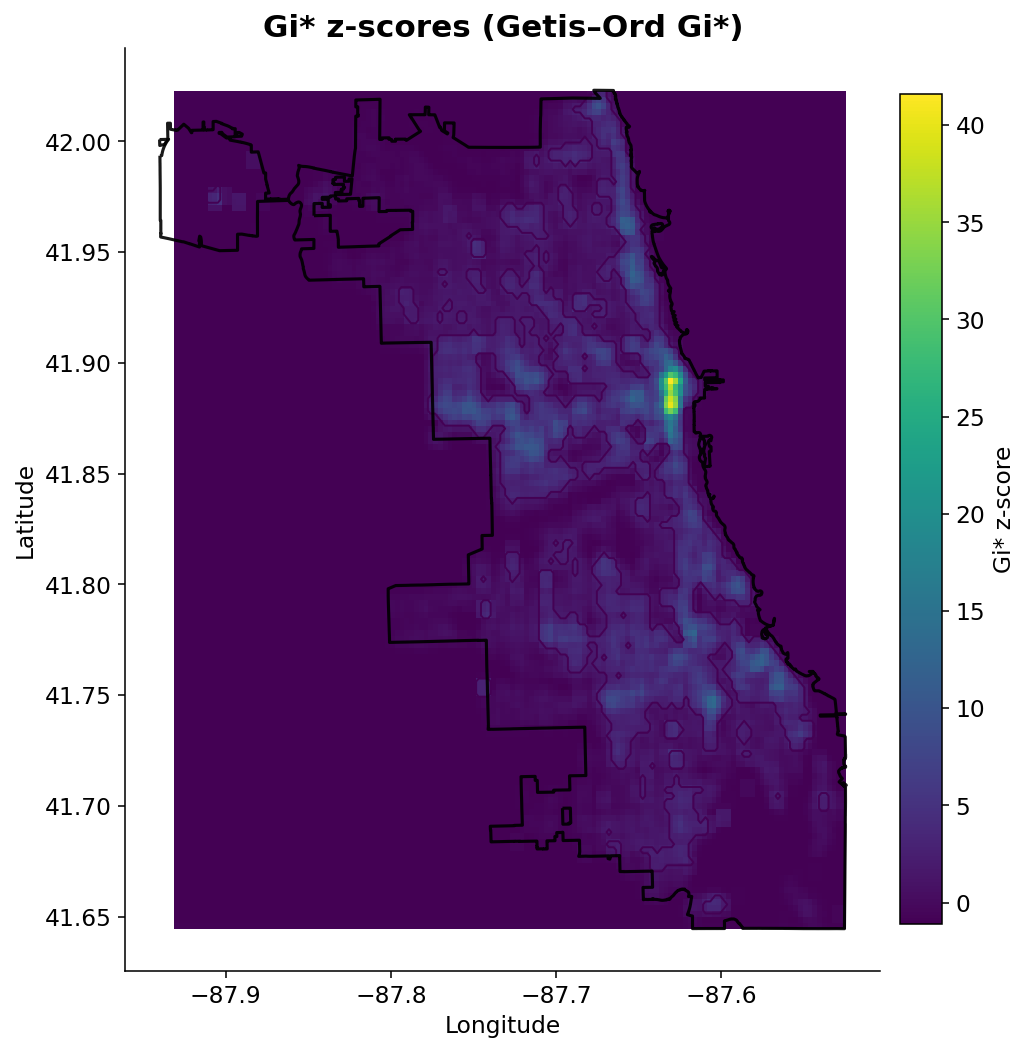

In [10]:

fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)
im = ax.imshow(
    z_gi, origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect="equal"
)
add_chicago_boundary(ax, city_gdf, lw=1.6)
ax.set_title("Gi* z-scores (Getis–Ord Gi*)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cb = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cb.set_label("Gi* z-score")
ax.contour(
    np.linspace(lon_min, lon_max, nx_g),
    np.linspace(lat_min, lat_max, ny_g),
    sig.astype(int), levels=[0.5], linewidths=1.0
)
fig.savefig("pretty_GiStar_zscores.png", dpi=300)
plt.show()

Figure Gi* z-scores (Hotspot strength with real-world support).
The Gi* z-score surface highlights the strength of local clustering and reveals a clear “core–periphery” structure. While most of the city remains near baseline (darker tones, z ≈ 0), an extremely compact high-value core appears on the eastern side near the lakefront, with peak z-scores exceeding 40. The intensity then decays outward from this core into a broader zone of moderate z-scores, indicating that the hotspot is not a single-cell spike but a concentrated nucleus embedded within a wider elevated region. This spatial form is consistent with high-exposure activity centers: areas near the urban core and lakefront typically feature higher pedestrian and vehicle flows, denser commercial and mixed-use land use, and more transit connectivity. To provide concrete real-world corroboration, subsequent EDA can overlay external layers and quantify overlap—e.g., proximity to CTA stations and transfer points, intersection/arterial road density, and densities of commercial POIs (restaurants, bars, retail) within buffers around hotspot cells—then compare these metrics between hotspot-core cells and non-hotspot areas. If the hotspot core systematically aligns with major transit/road nodes and high-activity POI clusters (and, optionally, strengthens during peak activity times), it would offer direct empirical support for the hypothesis that incident concentration is driven by concentrated human activity and exposure.
图 Gi* z-score（热点强度图）—加入现实佐证的写法（可直接替换原段）
Gi* z-score 强度图显示，除大部分区域 z-score 接近 0 外，城市东侧靠近湖岸的位置出现一个极其集中的高值核心（最大 z-score 超过 40），呈现出“热点核 + 向外衰减”的梯度结构。这类紧凑且强度极高的热点形态通常与“高暴露度活动中心”相吻合：在芝加哥，东侧临湖且接近市中心的区域往往同时具备更高的人流与车辆流量、商业与旅游设施密度，以及更强的交通连通性（主干道与公共交通站点密集）。因此，该热点核不仅可能反映事件发生的真实集中，也可能体现了人口活动与出行暴露在空间上的叠加效应。为进一步提供现实层面的佐证，后续可将热点网格与外部空间要素叠加检验：例如比较热点核与 CTA 车站/换乘点、主干道交叉口、商业 POI（餐饮、酒吧、零售）密度或旅游景点分布的空间重合程度；同时按时间维度分层（工作日/周末、白天/夜间）检验热点核是否在高人流时段更突出。若热点核与交通枢纽、商业娱乐集聚区或高人流走廊高度重合，并在相应时段显著增强，将构成对“热点由活动暴露驱动”的更直接证据。